- **Name:** Aj Kean Edoria
- **Term:** Term 2 S.Y 25-26

### Machine Problem 005: Time Response of First-Order Systems

The [Python Control Systems Library](https://github.com/python-control/python-control) provides tools to simulate and analyze the time response of control systems. In this notebook, we use it to study the **step response** of first-order systems — including how to identify poles and zeros, compute the time-domain response, and measure key performance specifications.

Consult the [Python Control Systems Documentation](http://python-control.readthedocs.io/en/latest/) for more details.

#### Installation

The [Python Control Systems Library](https://github.com/python-control/python-control) is not a standard part of most Python distributions. Run the following commands once to install the required packages.

To install both the Control Systems library and Slycot in an existing conda environment, run:
`!conda install -c conda-forge control slycot`

In [2]:
!conda install -c conda-forge slycot
!pip install control
!pip install seaborn

^C
^C


Traceback (most recent call last):
  File "C:\ProgramData\miniconda3\envs\control-system-cpe2a\Scripts\pip-script.py", line 9, in <module>
    sys.exit(main())
             ~~~~^^
  File "C:\ProgramData\miniconda3\envs\control-system-cpe2a\Lib\site-packages\pip\_internal\cli\main.py", line 47, in main
    from pip._internal.cli.autocompletion import autocomplete
  File "C:\ProgramData\miniconda3\envs\control-system-cpe2a\Lib\site-packages\pip\_internal\cli\autocompletion.py", line 12, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "C:\ProgramData\miniconda3\envs\control-system-cpe2a\Lib\site-packages\pip\_internal\cli\main_parser.py", line 11, in <module>
    from pip._internal.build_env import get_runnable_pip
  File "C:\ProgramData\miniconda3\envs\control-system-cpe2a\Lib\site-packages\pip\_internal\build_env.py", line 22, in <module>
    from pip._internal.cli.spinners import open_rich_spinner, open_spinner
  File "C:\ProgramData\miniconda3\envs\

#### Library Usage

The control systems library is designed to work with a simplified syntax where libraries are imported without the standard prefixes.

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import control.matlab as control

#### Demonstration

##### Poles and Zeros of a Transfer Function

Given a transfer function $G(s)$:

- **Poles** are values of $s$ that make $G(s) \to \infty$ (roots of the **denominator**)
- **Zeros** are values of $s$ that make $G(s) = 0$ (roots of the **numerator**)

Consider the transfer function from **Example 1** of the lecture:

$$G(s) = \frac{s + 2}{s + 5}$$

This system has:
- One **zero** at $s = -2$
- One **pole** at $s = -5$

We can compute and display these using the control library.

In [4]:
G1 = control.tf([1, 2], [1, 5])
print('Transfer Function G(s):')
print(G1)

poles = control.pole(G1)
zeros = control.zero(G1)

print(f'Poles: {poles}')
print(f'Zeros: {zeros}')

Transfer Function G(s):
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  s + 2
  -----
  s + 5
Poles: [-5.+0.j]
Zeros: [-2.+0.j]


We can visualize the pole-zero locations on the complex $s$-plane using a **pole-zero map**. Poles are marked with **×** and zeros with **○**.

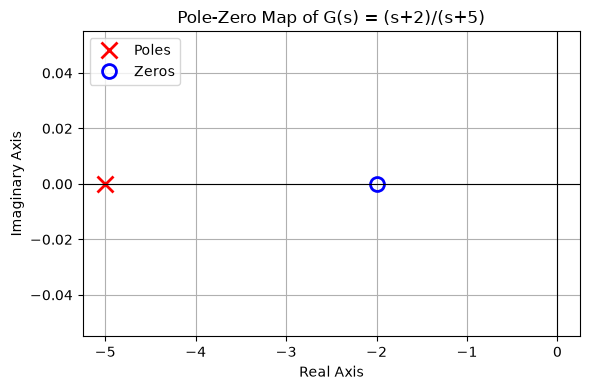

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

# Plot poles and zeros
ax.plot(poles.real, poles.imag, 'x', markersize=12, markeredgewidth=2,
        color='red', label='Poles')
ax.plot(zeros.real, zeros.imag, 'o', markersize=10, markerfacecolor='none',
        markeredgewidth=2, color='blue', label='Zeros')

# Draw axes
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)

ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis')
ax.set_title('Pole-Zero Map of G(s) = (s+2)/(s+5)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

The step response of this system combines contributions from both the forced response (due to the input) and the natural response (due to the pole). We compute it using `control.step()`.

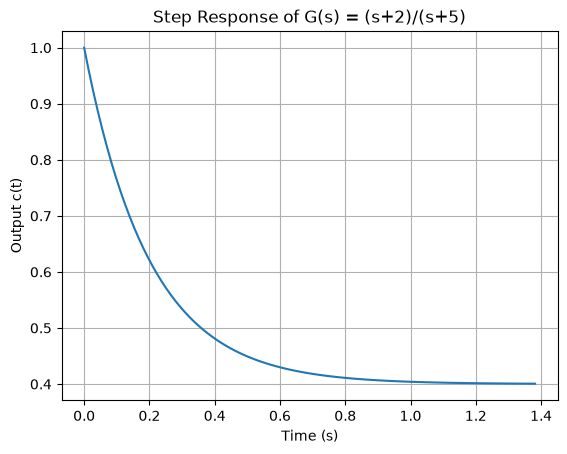

In [6]:
y, t = control.step(G1)

plt.figure()
plt.plot(t, y)
plt.xlabel('Time (s)')
plt.ylabel('Output c(t)')
plt.title('Step Response of G(s) = (s+2)/(s+5)')
plt.grid(True)
plt.show()

##### First-Order System Transfer Function

A **first-order system** has the general transfer function:

$$G(s) = \frac{a}{s + a}$$

This is also written in **time-constant form** as:

$$G(s) = \frac{K}{\tau s + 1}$$

where $\tau = \dfrac{1}{a}$ is the **time constant** and $K$ is the DC gain.

The system has one pole at $s = -a$ and **no finite zeros**.

For a **unit step input** $U(s) = \dfrac{1}{s}$, the output in the time domain is:

$$c(t) = K\left(1 - e^{-at}\right) = K\left(1 - e^{-t/\tau}\right)$$

Consider an example with $a = 3$, so $G(s) = \dfrac{3}{s + 3}$ and $\tau = \dfrac{1}{3}$ s.

In [7]:
a = 3          # pole location
tau = 1 / a   # time constant

G2 = control.tf([a], [1, a])
print('First-Order Transfer Function G(s):')
print(G2)
print(f'Pole at s = {-a}')
print(f'Time Constant τ = {tau:.4f} s')

First-Order Transfer Function G(s):
<TransferFunction>: sys[5]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    3
  -----
  s + 3
Pole at s = -3
Time Constant τ = 0.3333 s


##### Step Response and Time Specifications

For a first-order system, three key **transient response specifications** are defined:

| Specification | Symbol | Formula | Description |
|---|---|---|---|
| Time Constant | $\tau$ | $\tau = 1/a$ | Time to reach 63.2% of the final value |
| Rise Time | $T_r$ | $T_r \approx 2.2\tau$ | Time to go from 10% to 90% of the final value |
| Settling Time | $T_s$ | $T_s \approx 4\tau$ | Time to remain within 2% of the final value |

We compute and annotate these on the step response plot below.

Time Constant τ = 0.3333 s
Rise Time    Tr = 0.7333 s
Settling Time Ts = 1.3333 s


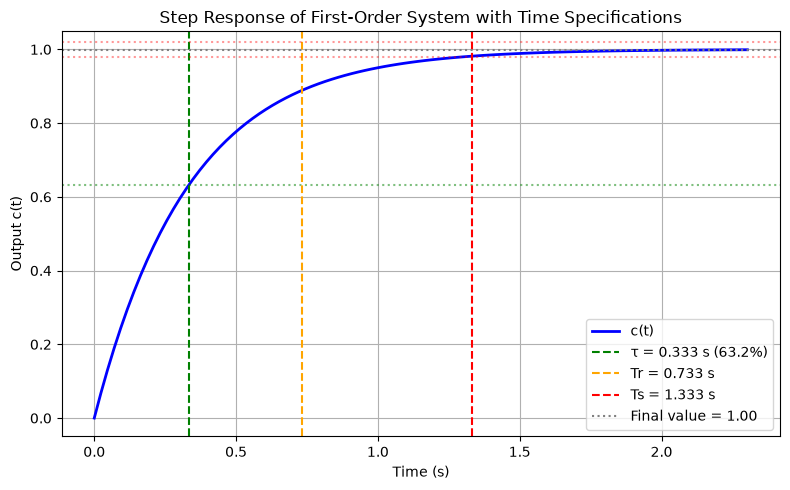

In [8]:
# Compute time specifications
tau = 1 / a
Tr  = 2.2 * tau   # Rise time  (10% to 90%)
Ts  = 4.0 * tau   # Settling time (2% criterion)

print(f'Time Constant τ = {tau:.4f} s')
print(f'Rise Time    Tr = {Tr:.4f} s')
print(f'Settling Time Ts = {Ts:.4f} s')

# Step response
y, t = control.step(G2)
c_final = y[-1]   # steady-state value

plt.figure(figsize=(8, 5))
plt.plot(t, y, 'b-', linewidth=2, label='c(t)')

# Annotate time constant (63.2%)
plt.axvline(tau, color='green', linestyle='--', label=f'τ = {tau:.3f} s (63.2%)')
plt.axhline(0.632 * c_final, color='green', linestyle=':', alpha=0.5)

# Annotate rise time (10%–90%)
plt.axvline(Tr, color='orange', linestyle='--', label=f'Tr = {Tr:.3f} s')

# Annotate settling time (2% band)
plt.axvline(Ts, color='red', linestyle='--', label=f'Ts = {Ts:.3f} s')
plt.axhline(0.98 * c_final, color='red', linestyle=':', alpha=0.4)
plt.axhline(1.02 * c_final, color='red', linestyle=':', alpha=0.4)

# Final value
plt.axhline(c_final, color='gray', linestyle=':', label=f'Final value = {c_final:.2f}')

plt.xlabel('Time (s)')
plt.ylabel('Output c(t)')
plt.title('Step Response of First-Order System with Time Specifications')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### Effect of the Pole Location on Response Speed

The pole location $s = -a$ directly determines how fast the system responds. A pole **farther from the origin** (larger $a$) produces a **faster** response with a smaller time constant.

We compare three first-order systems with different pole locations.

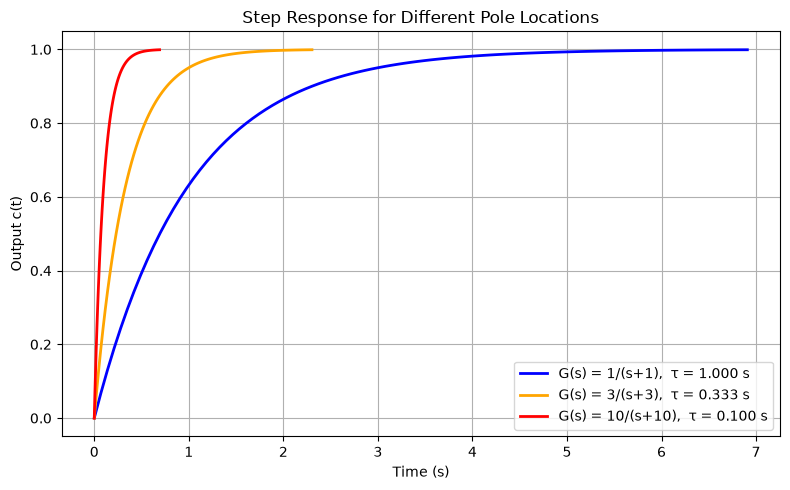


Summary Table:
  Pole (a)      τ (s)     Tr (s)     Ts (s)
---------------------------------------------
         1     1.0000     2.2000     4.0000
         3     0.3333     0.7333     1.3333
        10     0.1000     0.2200     0.4000


In [9]:
pole_locations = [1, 3, 10]   # values of 'a'
colors = ['blue', 'orange', 'red']

plt.figure(figsize=(8, 5))

for a_val, color in zip(pole_locations, colors):
    G = control.tf([a_val], [1, a_val])
    y, t = control.step(G)
    plt.plot(t, y, color=color, linewidth=2,
             label=f'G(s) = {a_val}/(s+{a_val}),  τ = {1/a_val:.3f} s')

plt.xlabel('Time (s)')
plt.ylabel('Output c(t)')
plt.title('Step Response for Different Pole Locations')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print('\nSummary Table:')
print(f'{"Pole (a)":>10} {"τ (s)":>10} {"Tr (s)":>10} {"Ts (s)":>10}')
print('-' * 45)
for a_val in pole_locations:
    tau = 1 / a_val
    print(f'{a_val:>10}  {tau:>9.4f}  {2.2*tau:>9.4f}  {4.0*tau:>9.4f}')

##### RC Circuit as a First-Order System

A series RC circuit is a classic example of a first-order system. The transfer function from input voltage $V_i(s)$ to capacitor voltage $V_C(s)$ is:

$$G(s) = \frac{V_C(s)}{V_i(s)} = \frac{1}{RCs + 1} = \frac{1/RC}{s + 1/RC}$$

where the time constant is $\tau = RC$.

Consider a circuit with $R = 1\,\text{k}\Omega$ and $C = 470\,\mu\text{F}$, driven by a 10 V step input.

RC Time Constant τ = RC = 0.4700 s
Pole location a = 1/τ = 2.1277 rad/s

RC Transfer Function G(s):
<TransferFunction>: sys[25]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    2.128
  ---------
  s + 2.128

Rise Time    Tr = 1.0340 s
Settling Time Ts = 1.8800 s


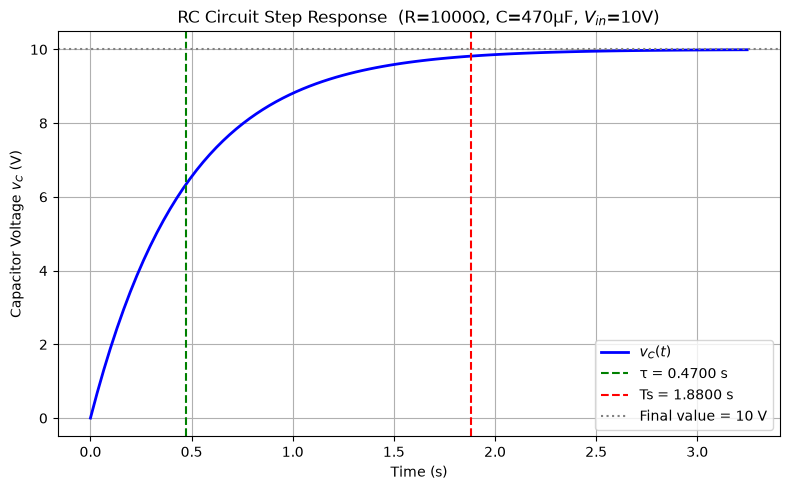

In [10]:
R = 1000        # Ohms  (1 kΩ)
C = 470e-6      # Farads (470 μF)
V_in = 10       # Volts  (step amplitude)

tau_RC = R * C
a_RC   = 1 / tau_RC

print(f'RC Time Constant τ = RC = {tau_RC:.4f} s')
print(f'Pole location a = 1/τ = {a_RC:.4f} rad/s')

# Transfer function: G(s) = (1/RC) / (s + 1/RC)
G_rc = control.tf([a_RC], [1, a_RC])
print('\nRC Transfer Function G(s):')
print(G_rc)

# Step response for V_in amplitude (scale the unit step)
y, t = control.step(G_rc)
v_C = V_in * y

# Time specifications
Tr_RC = 2.2 * tau_RC
Ts_RC = 4.0 * tau_RC
print(f'\nRise Time    Tr = {Tr_RC:.4f} s')
print(f'Settling Time Ts = {Ts_RC:.4f} s')

plt.figure(figsize=(8, 5))
plt.plot(t, v_C, 'b-', linewidth=2, label='$v_C(t)$')
plt.axvline(tau_RC, color='green', linestyle='--', label=f'τ = {tau_RC:.4f} s')
plt.axvline(Ts_RC,  color='red',   linestyle='--', label=f'Ts = {Ts_RC:.4f} s')
plt.axhline(V_in,   color='gray',  linestyle=':', label=f'Final value = {V_in} V')

plt.xlabel('Time (s)')
plt.ylabel('Capacitor Voltage $v_C$ (V)')
plt.title(f'RC Circuit Step Response  (R={R}Ω, C={C*1e6:.0f}μF, $V_{{in}}$={V_in}V)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
#### Exercises

Apply what you have learned from the demonstration above to solve the following problems. Add your code in the blank cells provided. Show all computed values and plots.

##### Exercise 1

Given the transfer function:

$$G(s) = \frac{s + 2}{s + 7}$$

*(a)* Identify the **poles** and **zeros** of the system.  
*(b)* Plot the **pole-zero map** on the $s$-plane.  
*(c)* Compute and plot the **step response** $c(t)$.  
*(d)* Based on the pole location, what is the **time constant** of the natural response?

=== Exercise 1 ===
(a) Poles: [-5.+0.j]  |  Zeros: [-2.+0.j]
(d) Time constant of natural response: τ = 1/7 ≈ 0.1429 s


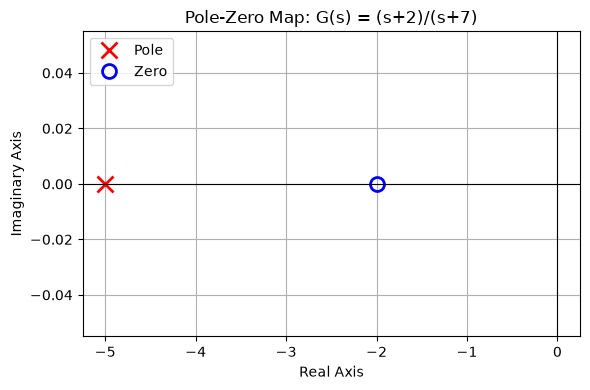

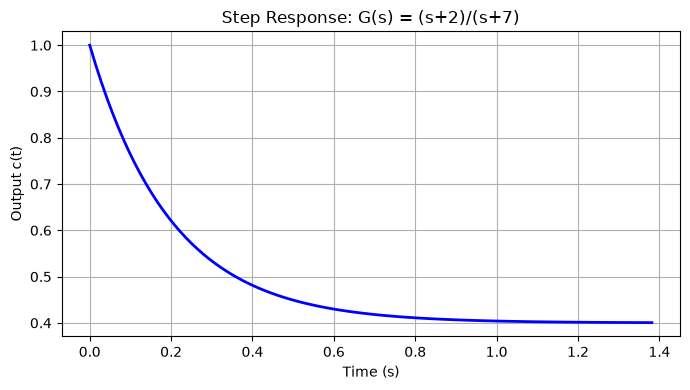

In [12]:
# Exercise 1 — your codG1 = control.tf([1, 2], [1, 7])
poles1 = control.pole(G1)
zeros1 = control.zero(G1)

print("=== Exercise 1 ===")
print(f"(a) Poles: {poles1}  |  Zeros: {zeros1}")
print(f"(d) Time constant of natural response: τ = 1/7 ≈ {1/7:.4f} s")

# (b) Pole-zero map
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(poles1.real, poles1.imag, 'rx', markersize=12, markeredgewidth=2, label='Pole')
ax.plot(zeros1.real, zeros1.imag, 'bo', markersize=10, markerfacecolor='none',
        markeredgewidth=2, label='Zero')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Real Axis'); ax.set_ylabel('Imaginary Axis')
ax.set_title('Pole-Zero Map: G(s) = (s+2)/(s+7)')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

# (c) Step response
y1, t1 = control.step(G1)
plt.figure(figsize=(7, 4))
plt.plot(t1, y1, 'b-', linewidth=2)
plt.xlabel('Time (s)'); plt.ylabel('Output c(t)')
plt.title('Step Response: G(s) = (s+2)/(s+7)')
plt.grid(True); plt.tight_layout(); plt.show()


##### Exercise 2

Given the transfer function:

$$G(s) = \frac{12}{s + 6}$$

*(a)* Identify the **pole** of the system.  
*(b)* Compute the **time constant** $\tau$, **rise time** $T_r$, and **settling time** $T_s$.  
*(c)* Compute and plot the **unit step response** $c(t)$.  
*(d)* Annotate the plot with vertical lines at $\tau$, $T_r$, and $T_s$ as shown in the demonstration.


=== Exercise 2 ===
(a) Pole at s = -6
(b) τ = 0.1667 s  |  Tr = 0.3667 s  |  Ts = 0.6667 s


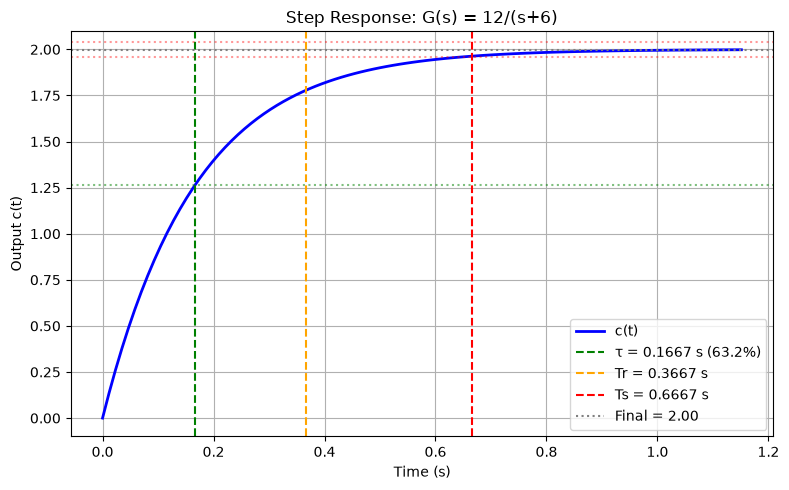

In [13]:
# Exercise 2 — your code here
a2 = 6
tau2 = 1 / a2
Tr2  = 2.2 * tau2
Ts2  = 4.0 * tau2

G2 = control.tf([12], [1, a2])
print("\n=== Exercise 2 ===")
print(f"(a) Pole at s = {-a2}")
print(f"(b) τ = {tau2:.4f} s  |  Tr = {Tr2:.4f} s  |  Ts = {Ts2:.4f} s")

# (c)+(d) Step response with annotations
y2, t2 = control.step(G2)
c_final2 = y2[-1]

plt.figure(figsize=(8, 5))
plt.plot(t2, y2, 'b-', linewidth=2, label='c(t)')
plt.axvline(tau2, color='green',  linestyle='--', label=f'τ = {tau2:.4f} s (63.2%)')
plt.axhline(0.632 * c_final2, color='green', linestyle=':', alpha=0.5)
plt.axvline(Tr2,  color='orange', linestyle='--', label=f'Tr = {Tr2:.4f} s')
plt.axvline(Ts2,  color='red',    linestyle='--', label=f'Ts = {Ts2:.4f} s')
plt.axhline(0.98 * c_final2, color='red', linestyle=':', alpha=0.4)
plt.axhline(1.02 * c_final2, color='red', linestyle=':', alpha=0.4)
plt.axhline(c_final2, color='gray', linestyle=':', label=f'Final = {c_final2:.2f}')
plt.xlabel('Time (s)'); plt.ylabel('Output c(t)')
plt.title('Step Response: G(s) = 12/(s+6)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

##### Exercise 3

An RC circuit has the following component values:

- $R = 2.2\,\text{k}\Omega$
- $C = 100\,\mu\text{F}$

The switch closes at $t = 0$ and the input voltage is a **unit step of 5 V**. Assume **zero initial conditions**.

*(a)* Determine the **transfer function** $G(s) = V_C(s)/V_i(s)$.  
*(b)* Compute the **time constant** $\tau$, **rise time** $T_r$, and **settling time** $T_s$.  
*(c)* Plot the **capacitor voltage** $v_C(t)$ over time.  
*(d)* At what time does $v_C(t)$ first reach **3.16 V**? *(Hint: this is related to one of the time specifications.)*


=== Exercise 3 ===
(a) G(s) = 4.5455 / (s + 4.5455)
(b) τ = 0.2200 s  |  Tr = 0.4840 s  |  Ts = 0.8800 s


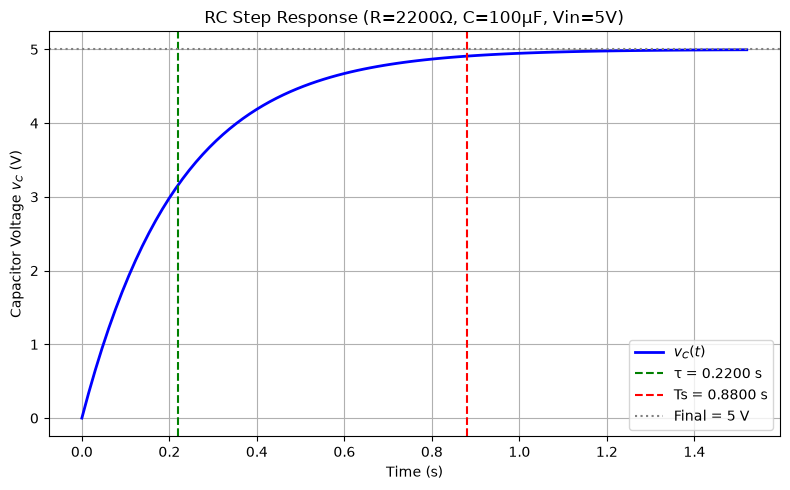

(d) vC(t) reaches 3.16 V at t = τ = 0.2200 s
    (3.16 V = 63.2% of 5 V, which is the definition of τ)


In [14]:
# Exercise 3 — your code here
R3   = 2200       # 2.2 kΩ
C3   = 100e-6     # 100 μF
Vin3 = 5          # V

tau3 = R3 * C3
a3   = 1 / tau3
Tr3  = 2.2 * tau3
Ts3  = 4.0 * tau3

print("\n=== Exercise 3 ===")
print(f"(a) G(s) = {a3:.4f} / (s + {a3:.4f})")
print(f"(b) τ = {tau3:.4f} s  |  Tr = {Tr3:.4f} s  |  Ts = {Ts3:.4f} s")

# (c) Plot vC(t)
G3 = control.tf([a3], [1, a3])
y3, t3 = control.step(G3)
vC3 = Vin3 * y3

plt.figure(figsize=(8, 5))
plt.plot(t3, vC3, 'b-', linewidth=2, label='$v_C(t)$')
plt.axvline(tau3, color='green', linestyle='--', label=f'τ = {tau3:.4f} s')
plt.axvline(Ts3,  color='red',   linestyle='--', label=f'Ts = {Ts3:.4f} s')
plt.axhline(Vin3, color='gray',  linestyle=':',  label=f'Final = {Vin3} V')
plt.xlabel('Time (s)'); plt.ylabel('Capacitor Voltage $v_C$ (V)')
plt.title(f'RC Step Response (R={R3}Ω, C={C3*1e6:.0f}μF, Vin={Vin3}V)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# (d) vC = 3.16 V → 3.16/5 = 0.632 → this is the 63.2% mark → t = τ
print(f"(d) vC(t) reaches 3.16 V at t = τ = {tau3:.4f} s")
print(f"    (3.16 V = 63.2% of 5 V, which is the definition of τ)")

##### Exercise 4

Three first-order systems are defined as follows:

$$G_A(s) = \frac{5}{s + 5} \qquad G_B(s) = \frac{5}{s + 2} \qquad G_C(s) = \frac{5}{s + 8}$$

*(a)* For each system, compute the **time constant** $\tau$, **rise time** $T_r$, and **settling time** $T_s$.  
*(b)* Plot all three **unit step responses** on the same figure with a legend.  
*(c)* Which system responds **fastest**? Which responds **slowest**? Explain your answer in terms of the **pole locations**.


=== Exercise 4 ===
(a)          System     Pole      τ (s)     Tr (s)     Ts (s)
----------------------------------------------------------
        GA: 5/(s+5)  s=  -5     0.2000     0.4400     0.8000
        GB: 5/(s+2)  s=  -2     0.5000     1.1000     2.0000
        GC: 5/(s+8)  s=  -8     0.1250     0.2750     0.5000


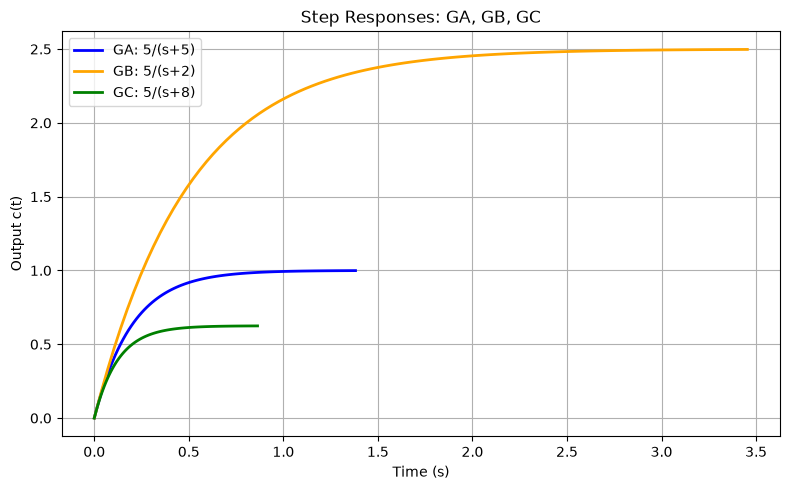


(c) GC (pole at s=-8) responds FASTEST — largest |pole|, smallest τ.
    GB (pole at s=-2) responds SLOWEST — smallest |pole|, largest τ.
    A pole farther from the origin means a shorter time constant.


In [15]:
# Exercise 4 — your code here
systems = {
    'GA: 5/(s+5)': 5,
    'GB: 5/(s+2)': 2,
    'GC: 5/(s+8)': 8,
}
colors = ['blue', 'orange', 'green']

print("\n=== Exercise 4 ===")
print(f"(a) {'System':>15} {'Pole':>8} {'τ (s)':>10} {'Tr (s)':>10} {'Ts (s)':>10}")
print('-' * 58)

plt.figure(figsize=(8, 5))

for (label, a_val), color in zip(systems.items(), colors):
    tau_val = 1 / a_val
    Tr_val  = 2.2 * tau_val
    Ts_val  = 4.0 * tau_val
    print(f"    {label:>15}  s={-a_val:>4}  {tau_val:>9.4f}  {Tr_val:>9.4f}  {Ts_val:>9.4f}")

    G = control.tf([5], [1, a_val])
    y, t = control.step(G)
    plt.plot(t, y, color=color, linewidth=2, label=label)

plt.xlabel('Time (s)'); plt.ylabel('Output c(t)')
plt.title('Step Responses: GA, GB, GC')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print("\n(c) GC (pole at s=-8) responds FASTEST — largest |pole|, smallest τ.")
print("    GB (pole at s=-2) responds SLOWEST — smallest |pole|, largest τ.")
print("    A pole farther from the origin means a shorter time constant.")